## Problem 2: Superimposed Sine Waves

**Goal**: Recover the unknown heat source $f(x,t)$.

**Given Solution ($u_{true}$)**:
$$u(x,t) = [\sin(\pi x) - 0.5\sin(2\pi x)] \sin(\pi t)$$

**Derived Source ($f_{true}$)**:
$$f = u_t - u_{xx}$$
$$f = \pi \cos(\pi t) [\sin(\pi x) - 0.5\sin(2\pi x)] + \pi^2 \sin(\pi t) [\sin(\pi x) - 2\sin(2\pi x)]$$

**Boundary Conditions**: 
$u(0,t) = 0, u(1,t) = 0$ (Dirichlet zero boundaries).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parameters and Grid Setup (Problem 2) ---
nx = 150      # number of intervals (or points – just be consistent)
nt = 50
alpha = 1.0 
L=1.0
x0, x1 = 0.0, 1.0
T = 0.5  

dx = (x1 - x0) / nx
dt = T / nt
x = np.linspace(x0, x1, nx)   # including boundaries
t = np.linspace(0.0, T,  nt)
X, T_mesh = np.meshgrid(x, t)

# Stability check
cfl_number = alpha * dt / (dx**2)
print(f"CFL Number: {cfl_number:.4f}")

CFL Number: 225.0000


## Ground Truth Data Generation (Method of Manufactured Solutions)

We use **Problem 1** to generate the synthetic "observed" data.

* **True Temperature ($u_{true}$)**: $u(x,t) = \sin(2\pi x) + \sin(\pi t)$
* **True Source ($f_{true}$)**: Derived analytically from the heat equation.

In [2]:
# --- 2. Ground Truth Generation (Problem 2) ---

# u(x,t) = [sin(pi*x) - 0.5*sin(2*pi*x)] * sin(pi*t)
u_true = (np.sin(np.pi * X) - 0.5 * np.sin(2 * np.pi * X)) * np.sin(np.pi * T_mesh)

# f calculations based on u_t - u_xx
# Term 1 (from u_t): pi * cos(pi*t) * [spatial_part]
term1 = np.pi * np.cos(np.pi * T_mesh) * (np.sin(np.pi * X) - 0.5 * np.sin(2 * np.pi * X))

# Term 2 (from -u_xx): pi^2 * sin(pi*t) * [sin(pi*x) - 2*sin(2*pi*x)]
term2 = (np.pi**2) * np.sin(np.pi * T_mesh) * (np.sin(np.pi * X) - 2 * np.sin(2 * np.pi * X))

f_true = term1 + term2

# Assume perfect observation
u_obs = u_true.copy()

## Solvers (Forward & Adjoint)

We implement two solvers using the Finite Difference Method:

1.  **Forward Solver**: Solves $u_t - u_{xx} = f$ forward in time to get $u$.
2.  **Adjoint Solver**: Solves $-p_t - p_{xx} = (u - u_{obs})$ backward in time to get the adjoint variable $p$.

The gradient of the cost function with respect to $f$ is simply the adjoint variable $p$.

In [3]:
# --- 3. Finite Difference Solvers (implicit, CFL-free) ---

def solve_forward(f_input):
    """
    Solves u_t - alpha u_xx = f forward in time with backward Euler
    and Dirichlet BCs taken from u_true.
    """
    u = np.zeros((nt, nx))

    # Initial condition and BCs from ground truth
    u[0, :]  = u_true[0, :]
    u[:, 0]  = u_true[:, 0]    # left boundary
    u[:, -1] = u_true[:, -1]   # right boundary

    # Interior grid size
    N_int = nx - 2

    # Backward Euler coefficient lambda = alpha * dt / dx^2
    lam = alpha * dt / (dx ** 2)

    # Matrix A = I - dt * alpha * L  (tri-diagonal, size N_int x N_int)
    main = (1.0 + 2.0 * lam) * np.ones(N_int)
    off  = -lam * np.ones(N_int - 1)
    A = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)

    for n in range(0, nt - 1):
        # BCs at time t_{n+1} (may be nonzero, taken from u_true)
        u[n+1, 0]  = u_true[n+1, 0]
        u[n+1, -1] = u_true[n+1, -1]

        # Right-hand side: u^n + dt * f^{n+1}
        rhs = u[n, 1:-1].copy() + dt * f_input[n+1, 1:-1]

        # Contributions from Dirichlet boundaries at n+1
        rhs[0]  += lam * u[n+1, 0]
        rhs[-1] += lam * u[n+1, -1]

        # Solve for interior at time n+1
        u[n+1, 1:-1] = np.linalg.solve(A, rhs)

    return u


def solve_adjoint(u_current, u_target):
    """
    Solves the adjoint equation

        -p_t - alpha p_xx = (u - u_target)

    backward in time using a backward-Euler-type discretization.
    Dirichlet adjoint BCs are homogeneous: p = 0 at x=0,1.
    """
    p = np.zeros((nt, nx))

    # Terminal condition p(T) = 0 already satisfied by initialization.

    N_int = nx - 2
    lam = alpha * dt / (dx ** 2)

    # Same matrix A = I - dt * alpha * L as in forward solve
    main = (1.0 + 2.0 * lam) * np.ones(N_int)
    off  = -lam * np.ones(N_int - 1)
    A = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)

    # Backward in time: n = nt-2, ..., 0
    for n in range(nt - 2, -1, -1):
        # Homogeneous Dirichlet BCs for adjoint
        p[n, 0]  = 0.0
        p[n, -1] = 0.0

        # Residual at time t_{n+1}
        residual = u_current[n+1, 1:-1] - u_target[n+1, 1:-1]

        # Discrete adjoint step:
        # (I - dt * alpha * L) p^n = p^{n+1} - dt * residual^{n+1}
        rhs = p[n+1, 1:-1] - dt * residual

        # No boundary contribution since adjoint BCs are zero
        p[n, 1:-1] = np.linalg.solve(A, rhs)

    return p


## Optimization Loop

We iterate to minimize the objective function.

**Configuration**:
* **Learning Rate**: Step size for gradient descent.
* **Non-negativity Constraint**: If `True`, we enforce $f \ge 0$ at every step (Projected Gradient Descent).
    * *Note*: For Problem 1, the true $f$ contains negative values. Enabling this constraint will prevent convergence to the exact true solution, but is often required in real-world physical problems (e.g., heating only).

In [4]:
# # --- 4A. Optimization Loop ---

# # Settings
# LEARNING_RATE = 5.0
# EPOCHS = 5000
# ENABLE_NON_NEGATIVITY = False
# LAMBDA_REG = 0.0            

# # Initialization
# f_guess = np.zeros((nt, nx))
# loss_history = []

# print(f"Starting optimization with Non-negativity Constraint: {ENABLE_NON_NEGATIVITY}")

# for epoch in range(EPOCHS + 1):
#     # A. Forward Pass
#     u_pred = solve_forward(f_guess)

#     # B. Loss = data misfit + regularization
#     misfit = u_pred - u_obs
#     data_term = 0.5 * np.sum(misfit**2) * dx * dt
#     reg_term  = 0.5 * LAMBDA_REG * np.sum(f_guess**2) * dx * dt
#     loss = data_term + reg_term
#     loss_history.append(loss)

#     # C. Adjoint
#     p = solve_adjoint(u_pred, u_obs)

#     # D. Gradient of J wrt f  ***FIX HERE***
#     # ∇J(f) = LAMBDA_REG * f - p
#     gradient = LAMBDA_REG * f_guess - p

#     # E. Gradient descent step (only interior points)
#     f_guess[1:-1, 1:-1] -= LEARNING_RATE * gradient[1:-1, 1:-1]

#     # F. Projection (optional non-negativity)
#     if ENABLE_NON_NEGATIVITY:
#         f_guess = np.maximum(f_guess, 0.0)

#     if epoch % 50 == 0:
#         print(f"Epoch {epoch}: Loss = {loss:.6e}")


In [5]:
# # time axis: nt points, space axis: nx points
# time_slices = [1, nt // 2, nt - 2]   # pick whatever you agreed on

# fig, axes = plt.subplots(len(time_slices), 1, figsize=(10, 8))

# for idx, t_idx in enumerate(time_slices):
#     axes[idx].plot(x, f_true[t_idx, :], label='True f', linewidth=2)
#     axes[idx].plot(x, f_guess[t_idx, :], '--', label='Adjoint learned f', linewidth=2)
#     axes[idx].set_ylabel('f(x,t)')
#     axes[idx].set_title(f't = {t[t_idx]:.3f}')
#     axes[idx].grid(True, alpha=0.3)
#     axes[idx].legend()

# axes[-1].set_xlabel('x')

# plt.tight_layout()
# plt.show()

# # u_true is already the manufactured solution on the grid (nt, nx)
# u_traj_true = u_true

# # run your forward solver from the *learned* forcing
# u_traj_learned = solve_forward(f_guess)

# fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# # True u
# im0 = axes[0].imshow(
#     u_traj_true,
#     aspect='auto',
#     origin='lower',
#     extent=[x[0], x[-1], t[0], t[-1]],
#     cmap='hot'
# )
# axes[0].set_title('u_true(x,t)')
# axes[0].set_xlabel('x')
# axes[0].set_ylabel('t')
# fig.colorbar(im0, ax=axes[0])

# # Learned u
# im1 = axes[1].imshow(
#     u_traj_learned,
#     aspect='auto',
#     origin='lower',
#     extent=[x[0], x[-1], t[0], t[-1]],
#     cmap='hot'
# )
# axes[1].set_title('u_learned(x,t) (Adjoint)')
# axes[1].set_xlabel('x')
# axes[1].set_ylabel('t')
# fig.colorbar(im1, ax=axes[1])

# # Difference
# im2 = axes[2].imshow(
#     u_traj_true - u_traj_learned,
#     aspect='auto',
#     origin='lower',
#     extent=[x[0], x[-1], t[0], t[-1]],
#     cmap='RdBu'
# )
# axes[2].set_title('u_true - u_learned')
# axes[2].set_xlabel('x')
# axes[2].set_ylabel('t')
# fig.colorbar(im2, ax=axes[2])

# plt.tight_layout()
# plt.show()


In [6]:
# --- 4B. Optimization Loop ---

# Settings
LEARNING_RATE = 5.0
EPOCHS = 5000
ENABLE_NON_NEGATIVITY = True
LAMBDA_REG = 0.0            

# Initialization
f_guess = np.zeros((nt, nx))
loss_history = []

print(f"Starting optimization with Non-negativity Constraint: {ENABLE_NON_NEGATIVITY}")

for epoch in range(EPOCHS + 1):
    # A. Forward Pass
    u_pred = solve_forward(f_guess)

    # B. Loss = data misfit + regularization
    misfit = u_pred - u_obs
    data_term = 0.5 * np.sum(misfit**2) * dx * dt
    reg_term  = 0.5 * LAMBDA_REG * np.sum(f_guess**2) * dx * dt
    loss = data_term + reg_term
    loss_history.append(loss)

    # C. Adjoint
    p = solve_adjoint(u_pred, u_obs)

    # D. Gradient of J wrt f  ***FIX HERE***
    # ∇J(f) = LAMBDA_REG * f - p
    gradient = LAMBDA_REG * f_guess - p

    # E. Gradient descent step (only interior points)
    f_guess[1:-1, 1:-1] -= LEARNING_RATE * gradient[1:-1, 1:-1]

    # F. Projection (optional non-negativity)
    if ENABLE_NON_NEGATIVITY:
        f_guess = np.maximum(f_guess, 0.0)

    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.6e}")


Starting optimization with Non-negativity Constraint: True
Epoch 0: Loss = 7.760417e-02
Epoch 50: Loss = 1.397633e-02
Epoch 100: Loss = 9.167976e-03
Epoch 150: Loss = 6.901801e-03
Epoch 200: Loss = 5.561499e-03
Epoch 250: Loss = 4.705426e-03
Epoch 300: Loss = 4.117250e-03
Epoch 350: Loss = 3.691077e-03
Epoch 400: Loss = 3.370259e-03
Epoch 450: Loss = 3.121277e-03
Epoch 500: Loss = 2.923669e-03
Epoch 550: Loss = 2.763725e-03
Epoch 600: Loss = 2.632165e-03
Epoch 650: Loss = 2.522512e-03
Epoch 700: Loss = 2.430212e-03
Epoch 750: Loss = 2.351690e-03
Epoch 800: Loss = 2.284334e-03
Epoch 850: Loss = 2.226083e-03
Epoch 900: Loss = 2.175387e-03
Epoch 950: Loss = 2.130957e-03
Epoch 1000: Loss = 2.091909e-03
Epoch 1050: Loss = 2.057259e-03
Epoch 1100: Loss = 2.026626e-03
Epoch 1150: Loss = 1.999109e-03
Epoch 1200: Loss = 1.974656e-03
Epoch 1250: Loss = 1.952519e-03
Epoch 1300: Loss = 1.932629e-03
Epoch 1350: Loss = 1.914660e-03
Epoch 1400: Loss = 1.898249e-03
Epoch 1450: Loss = 1.883449e-03
Epoc

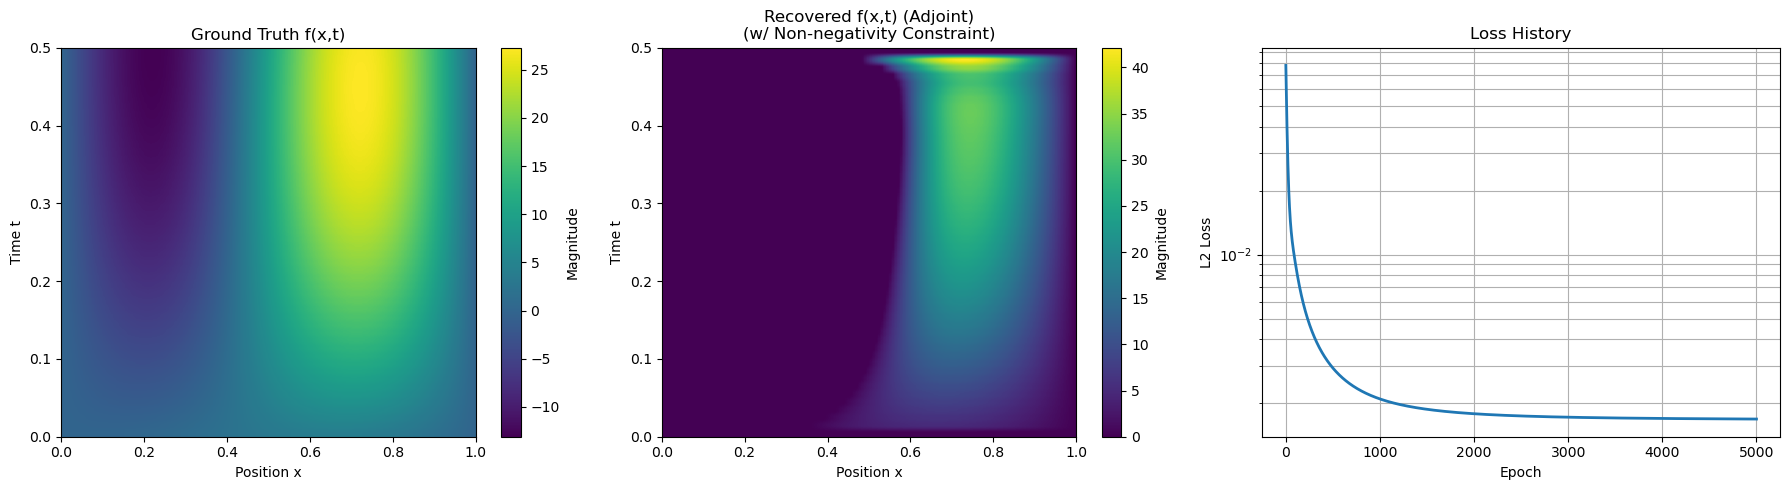

In [7]:
# --- 5B. Visualization ---

plt.figure(figsize=(18, 5))

# Plot 1: True Source Term
plt.subplot(1, 3, 1)
plt.title("Ground Truth f(x,t)")
plt.imshow(f_true, aspect='auto', extent=[0, L, 0, T], origin='lower', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Position x')
plt.ylabel('Time t')

# Plot 2: Recovered Source Term
plt.subplot(1, 3, 2)
title_str = "Recovered f(x,t) (Adjoint)"
if ENABLE_NON_NEGATIVITY:
    title_str += "\n(w/ Non-negativity Constraint)"
plt.title(title_str)
plt.imshow(f_guess, aspect='auto', extent=[0, L, 0, T], origin='lower', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Position x')
plt.ylabel('Time t')

# Plot 3: Loss Convergence
plt.subplot(1, 3, 3)
plt.title("Loss History")
plt.plot(loss_history, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('L2 Loss')
plt.yscale('log')
plt.grid(True, which="both", ls="-")

plt.tight_layout()
plt.show()


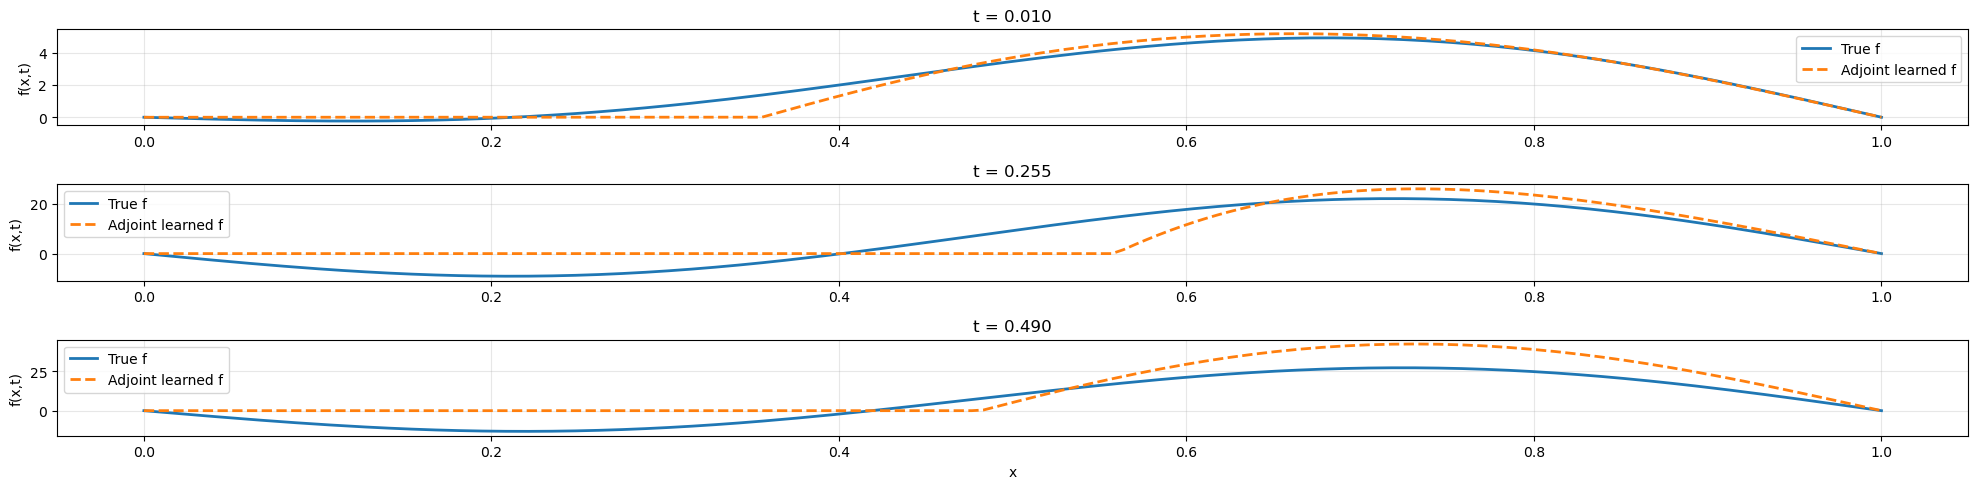

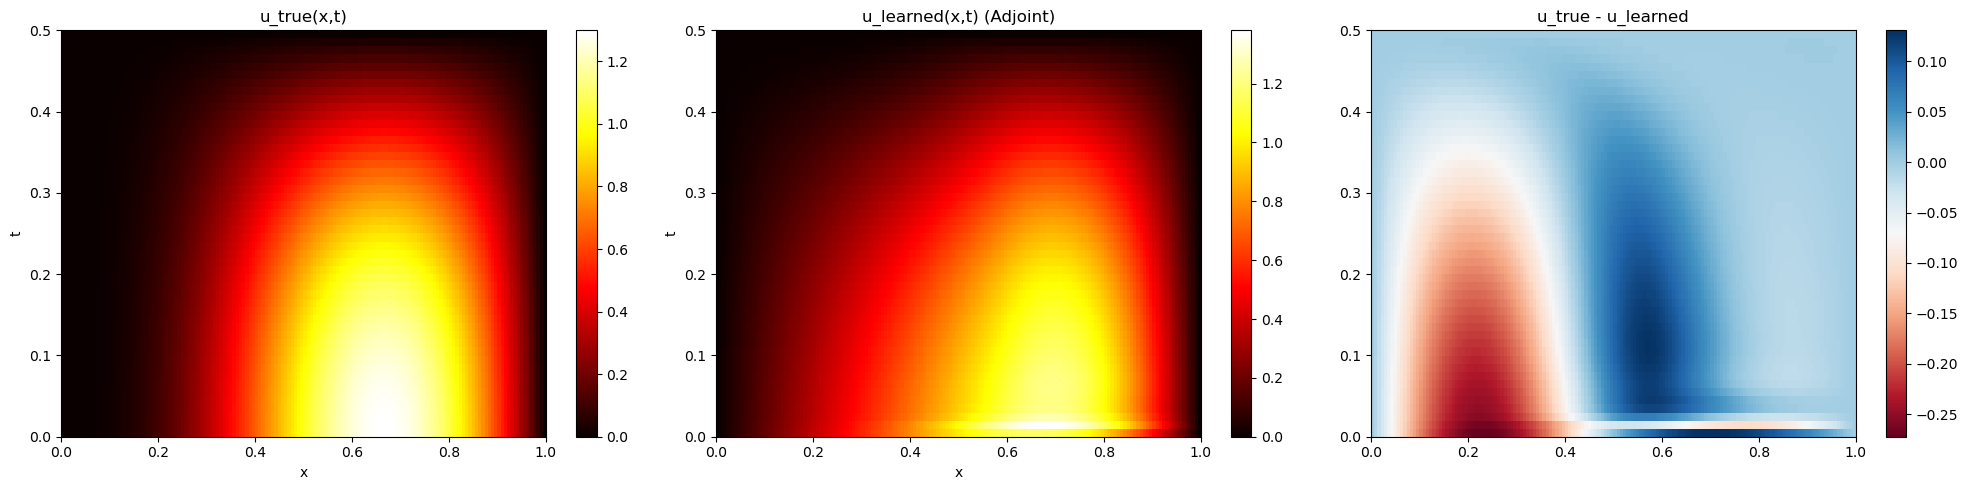

In [15]:

# time axis: nt points, space axis: nx points
time_slices = [1, nt // 2, nt - 2]   # pick whatever you agreed on

fig, axes = plt.subplots(len(time_slices), 1, figsize=(20, 5))

for idx, t_idx in enumerate(time_slices):
    axes[idx].plot(x, f_true[t_idx, :], label='True f', linewidth=2)
    axes[idx].plot(x, f_guess[t_idx, :], '--', label='Adjoint learned f', linewidth=2)
    axes[idx].set_ylabel('f(x,t)')
    axes[idx].set_title(f't = {t[t_idx]:.3f}')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

axes[-1].set_xlabel('x')

plt.tight_layout()
plt.show()

# u_true is already the manufactured solution on the grid (nt, nx)
u_traj_true = u_true

# run your forward solver from the *learned* forcing
u_traj_learned = solve_forward(f_guess)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# True u
im0 = axes[0].imshow(
    u_traj_true,
    aspect='auto',
    origin='upper',
    extent=[x[0], x[-1], t[0], t[-1]],
    cmap='hot'
)
axes[0].set_title('u_true(x,t)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
fig.colorbar(im0, ax=axes[0])

# Learned u
im1 = axes[1].imshow(
    u_traj_learned,
    aspect='auto',
    origin='upper',
    extent=[x[0], x[-1], t[0], t[-1]],
    cmap='hot'
)
axes[1].set_title('u_learned(x,t) (Adjoint)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
fig.colorbar(im1, ax=axes[1])

# Difference
im2 = axes[2].imshow(
    u_traj_true - u_traj_learned,
    aspect='auto',
    origin='upper',
    extent=[x[0], x[-1], t[0], t[-1]],
    cmap='RdBu'
)
axes[2].set_title('u_true - u_learned')
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()


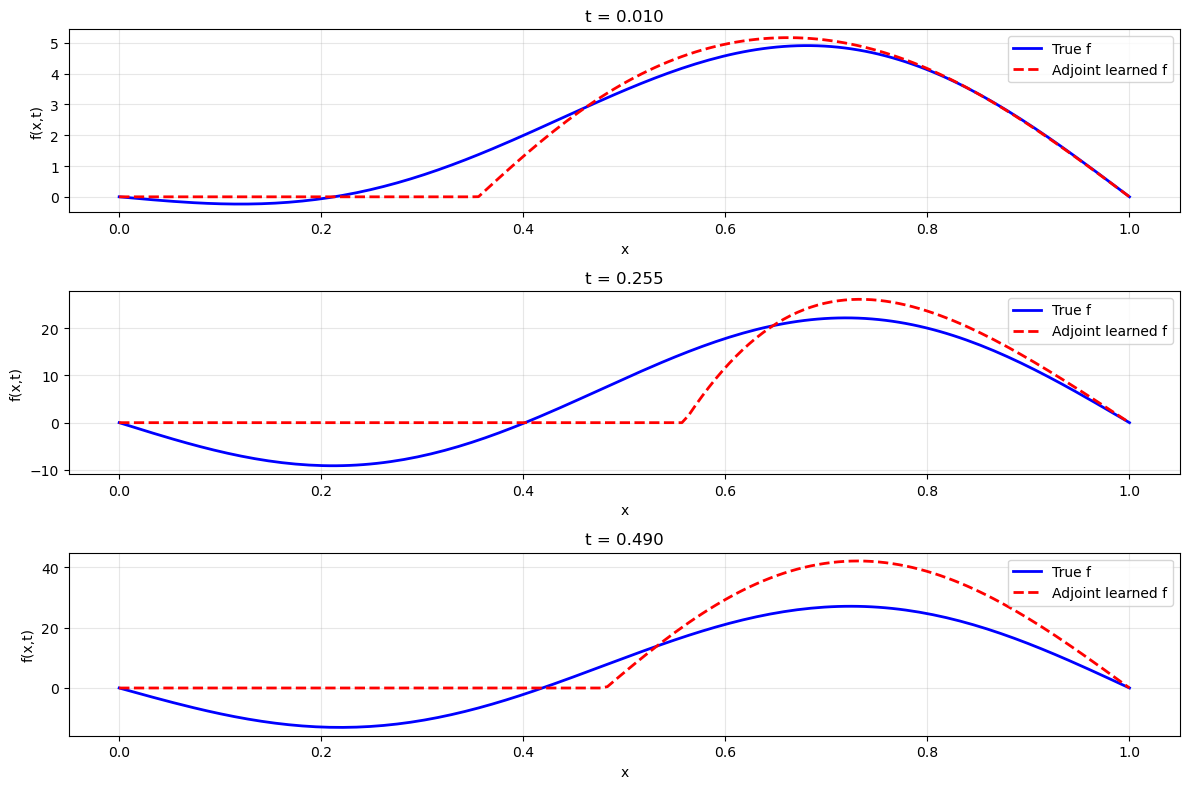

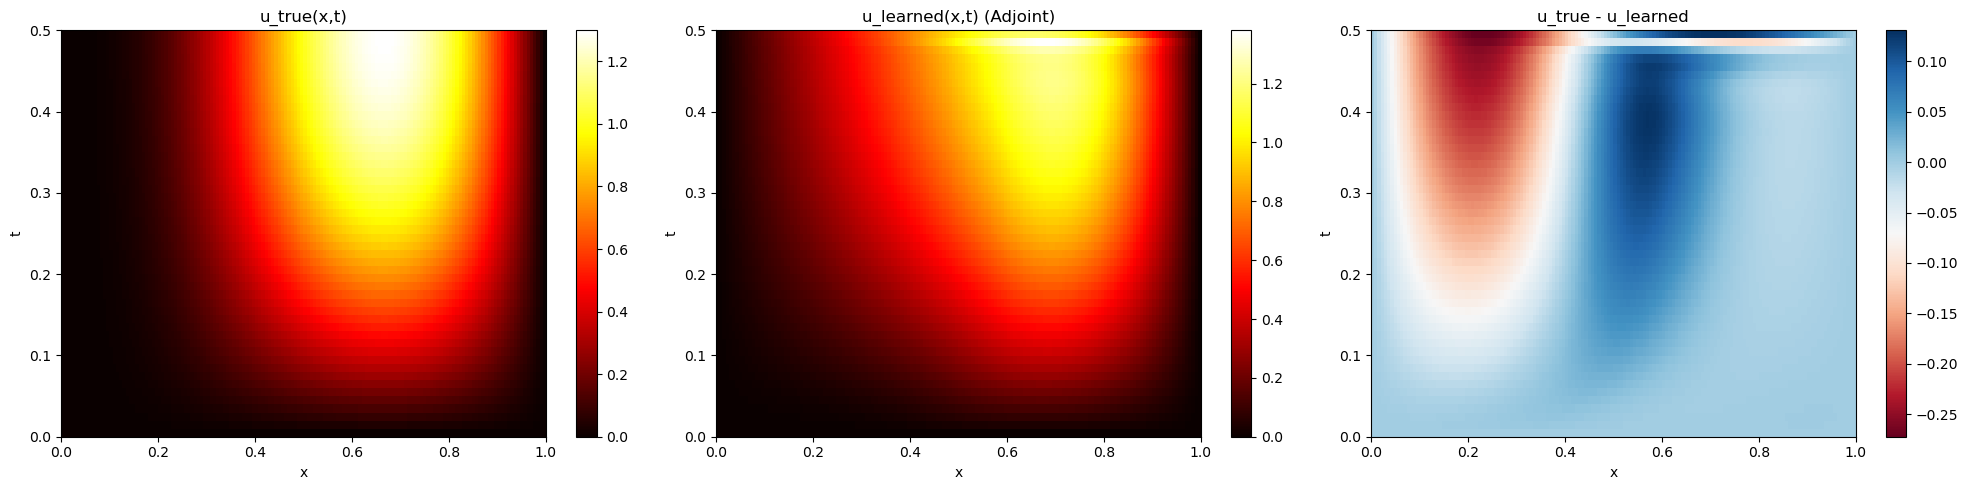

In [ ]:
# time_slices = [1, nt // 2, nt - 2]   # pick whatever you agreed on


# fig, axes = plt.subplots(3, 1, figsize=(12, 8))
# for idx, t_idx in enumerate(time_slices):
#     axes[idx].plot(x, f_true[t_idx, :], 'b-', label='True f', linewidth=2)
#     axes[idx].plot(x, f_guess[t_idx, :], 'r--', label='Adjoint learned f', linewidth=2)
#     axes[idx].set_ylabel('f(x,t)')
#     axes[idx].set_title(f't = {t[t_idx]:.3f}')
#     axes[idx].grid(True, alpha=0.3)
#     axes[idx].legend()

# axes[-1].set_xlabel('x')

# plt.tight_layout()
# plt.show()


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
time_slices = [1, nt // 2, nt - 2] 
for idx, t_idx in enumerate(time_slices):
    axes[idx].plot(x, f_true[t_idx], 'b-', label='True f', linewidth=2)
    axes[idx].plot(x, f_guess[t_idx], 'r--', label='Adjoint learned f', linewidth=2)
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('f(x,t)')
    axes[idx].set_title(f't = {t[t_idx]:.3f}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



# u_true is already the manufactured solution on the grid (nt, nx)
u_traj_true = u_true

# run your forward solver from the *learned* forcing
u_traj_learned = solve_forward(f_guess)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# True u
im0 = axes[0].imshow(
    u_traj_true,
    aspect='auto',
    origin='lower',
    extent=[x[0], x[-1], t[0], t[-1]],
    cmap='hot'
)
axes[0].set_title('u_true(x,t)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
fig.colorbar(im0, ax=axes[0])

# Learned u
im1 = axes[1].imshow(
    u_traj_learned,
    aspect='auto',
    origin='lower',
    extent=[x[0], x[-1], t[0], t[-1]],
    cmap='hot'
)
axes[1].set_title('u_learned(x,t) (Adjoint)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
fig.colorbar(im1, ax=axes[1])

# Difference
im2 = axes[2].imshow(
    u_traj_true - u_traj_learned,
    aspect='auto',
    origin='lower',
    extent=[x[0], x[-1], t[0], t[-1]],
    cmap='RdBu'
)
axes[2].set_title('u_true - u_learned')
axes[2].set_xlabel('x')
axes[2].set_ylabel('t')
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()


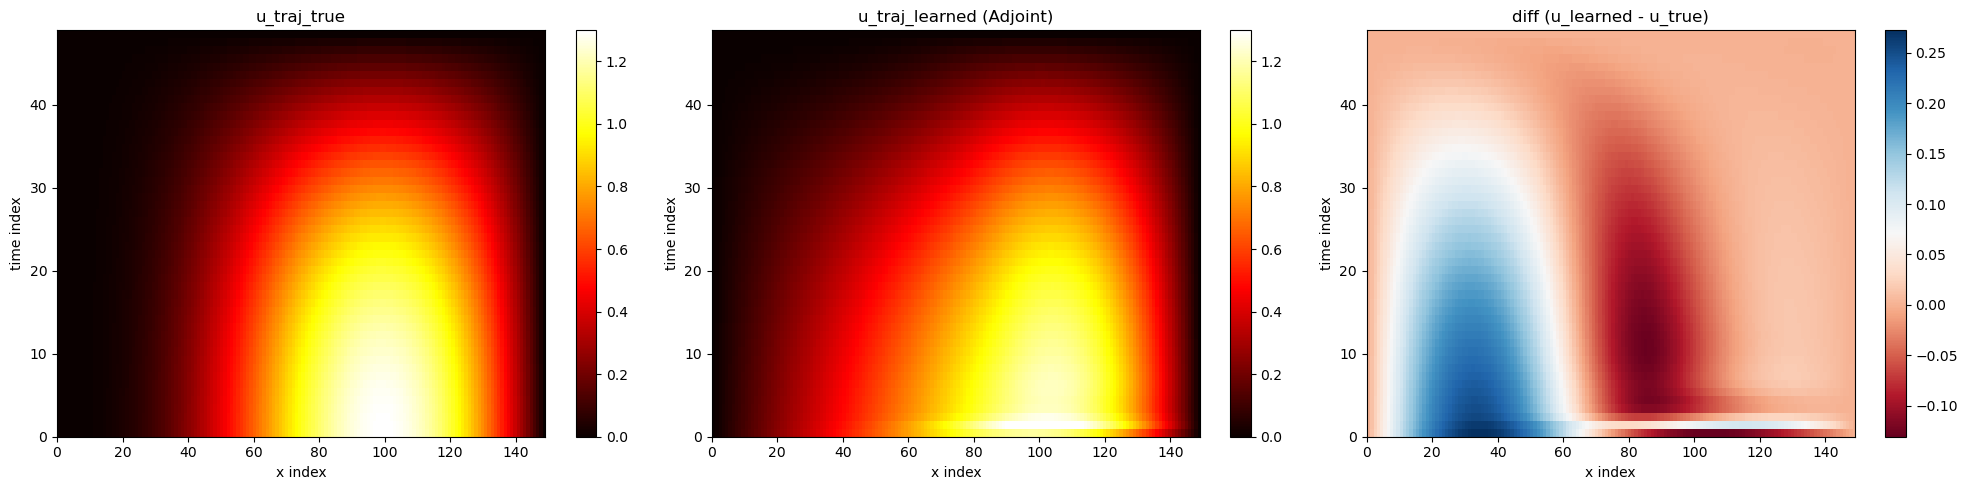

In [11]:
nt, nx = u_traj_true.shape

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# use the same color range for both true and learned
vmin = np.min(u_traj_true)
vmax = np.max(u_traj_true)

# we plot in index coordinates to match your teammate:
# x-axis: 0 ... nx-1, y-axis (time index): 0 ... nt-1 (0 at top)
extent = [0, nx-1, 0, nt-1]

# --- u_true ---
im0 = axes[0].imshow(
    u_traj_true,
    aspect='auto',
    cmap='hot',
    origin='upper',      # time index 0 at the top
    extent=extent,
    vmin=vmin,
    vmax=vmax,
)
axes[0].set_title("u_traj_true")
axes[0].set_xlabel("x index")
axes[0].set_ylabel("time index")
fig.colorbar(im0, ax=axes[0])

# --- u_learned ---
im1 = axes[1].imshow(
    u_traj_learned,
    aspect='auto',
    cmap='hot',
    origin='upper',
    extent=extent,
    vmin=vmin,
    vmax=vmax,
)
axes[1].set_title("u_traj_learned (Adjoint)")
axes[1].set_xlabel("x index")
axes[1].set_ylabel("time index")
fig.colorbar(im1, ax=axes[1])

# --- diff ---
diff = u_traj_learned - u_traj_true   # match their sign; flip if needed
im2 = axes[2].imshow(
    diff,
    aspect='auto',
    cmap='RdBu',
    origin='upper',
    extent=extent,
)
axes[2].set_title("diff (u_learned - u_true)")
axes[2].set_xlabel("x index")
axes[2].set_ylabel("time index")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()
